In [1]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [1]:
import cv2
import mediapipe as mp
import math
from google.colab.patches import cv2_imshow
from google.colab import files

In [2]:
# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

In [7]:
print("Please upload an image of a hand...")
uploaded = files.upload()

Please upload an image of a hand...


Saving female-hand.webp to female-hand.webp


In [8]:
if uploaded:
    image_name = list(uploaded.keys())[0]

    img = cv2.imread(image_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [9]:
import warnings
warnings.filterwarnings('ignore')

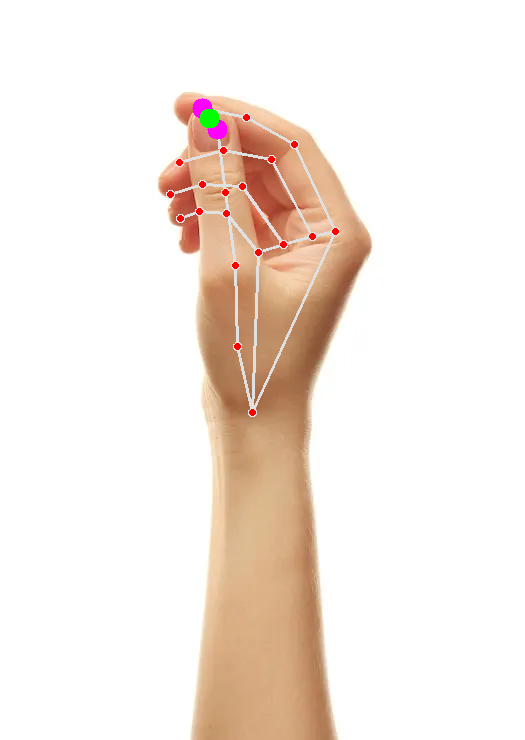

In [10]:
results = hands.process(img_rgb)
if results.multi_hand_landmarks:

  for hand_landmarks in results.multi_hand_landmarks:
    mp_draw.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)
    index_tip = hand_landmarks.landmark[8]
    thumb_tip = hand_landmarks.landmark[4]

    h, w, c = img.shape
    ix, iy = int(index_tip.x * w), int(index_tip.y * h)
    tx, ty = int(thumb_tip.x * w), int(thumb_tip.y * h)

    cv2.circle(img, (ix, iy), 10, (255, 0, 255), cv2.FILLED)
    cv2.circle(img, (tx, ty), 10, (255, 0, 255), cv2.FILLED)
    cv2.line(img, (ix, iy), (tx, ty), (255, 0, 255), 3)
    distance = math.hypot(tx - ix, ty - iy)
    if distance < 40:
      gesture = "Pinch (Click!)"
      cv2.circle(img, ((ix + tx) // 2, (iy + ty) // 2), 10, (0, 255, 0), cv2.FILLED)
    else:
      gesture = "Open/Idle"
      cv2.putText(img, f'Gesture: {gesture}', (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
      print(f"Detected Gesture: {gesture}")

  cv2_imshow(img)
  cv2.waitKey(0)
  cv2.destroyAllWindows()
else:
  print("No hand detected in the image.")